# YOLO Pose -> SD 1.5 + ControlNet OpenPose Avatar

Pipeline:
1. **Setup** - install deps, load YOLOv8-pose, SD 1.5, and ControlNet-OpenPose into VRAM.
2. **Upload** - upload a photo, run YOLO pose, render OpenPose-style skeleton.
3. **Generate** - feed skeleton into SD 1.5 + ControlNet to produce an avatar (target: <=30 s on a T4).

Make sure the runtime is set to **GPU** (Runtime -> Change runtime type -> T4 GPU).

## Cell 1 - Setup (run once)

Installs packages and pre-downloads / pre-loads all weights into GPU memory so the generation cell only does inference.

In [3]:
# --- Install dependencies ---
import subprocess, sys

def pip_install(pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

# Newer diffusers no longer references the removed `cached_download` from
# huggingface_hub, so these pins resolve cleanly on current Colab images.
pip_install([
    'diffusers==0.31.0',
    'transformers==4.46.3',
    'accelerate==1.1.1',
    'huggingface_hub==0.26.2',
    'safetensors',
    'ultralytics==8.3.40',
    'opencv-python-headless',
    'Pillow',
    'pillow-heif',   # lets PIL open iPhone HEIC/HEIF photos
])
# GFPGAN (stage 3: face restoration) + its deps.
pip_install(['gfpgan==1.3.8', 'basicsr==1.4.2', 'facexlib==0.3.0'])

import torch, numpy as np, cv2
from PIL import Image

# Register HEIC/HEIF support so Image.open() can read iPhone photos.
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
except Exception as e:
    print('pillow-heif not available:', e)

# basicsr (a GFPGAN dependency) imports a torchvision symbol that newer
# torchvision moved. Shim it so the import works on current Colab.
import types
import torchvision.transforms.functional as _tvF
_shim = types.ModuleType('torchvision.transforms.functional_tensor')
_shim.rgb_to_grayscale = _tvF.rgb_to_grayscale
sys.modules['torchvision.transforms.functional_tensor'] = _shim

from ultralytics import YOLO
from diffusers import (
    StableDiffusionControlNetPipeline,
    StableDiffusionImg2ImgPipeline,
    ControlNetModel,
    DPMSolverMultistepScheduler,
)
from gfpgan import GFPGANer

assert torch.cuda.is_available(), 'No GPU detected. Set Runtime -> Change runtime type -> T4 GPU.'
device = 'cuda'
dtype = torch.float16
print('GPU:', torch.cuda.get_device_name(0))

# --- Load YOLO11 pose (nano: fast download, very good keypoints) ---
yolo_pose = YOLO('yolo11n-pose.pt')
print('YOLO11n-pose loaded.')

# --- Load ControlNet OpenPose + SD 1.5 checkpoint ---
# DreamShaper-8 is an SD-1.5 checkpoint tuned for stylized/cinematic output -> great
# for masked heroes (Spider-Man etc.). For neutral realism revert to:
#   SD_MODEL = 'stable-diffusion-v1-5/stable-diffusion-v1-5'
SD_MODEL = 'Lykon/dreamshaper-8'
CN_MODEL = 'lllyasviel/control_v11p_sd15_openpose'

controlnet = ControlNetModel.from_pretrained(CN_MODEL, torch_dtype=dtype)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    SD_MODEL,
    controlnet=controlnet,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)
# DreamShaper ships a 'deis'/final_sigmas_type='zero' scheduler config; override
# algorithm_type so DPM-Solver++ accepts it.
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config, algorithm_type='dpmsolver++')
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=True)
try:
    pipe.enable_xformers_memory_efficient_attention()
except Exception:
    pass

# --- Img2img pipe for the detailer pass (stage 2.5). ---
# Reuses the SAME weights already in VRAM -> no extra model / no extra download.
img2img = StableDiffusionImg2ImgPipeline(
    vae=pipe.vae,
    text_encoder=pipe.text_encoder,
    tokenizer=pipe.tokenizer,
    unet=pipe.unet,
    scheduler=pipe.scheduler,
    safety_checker=None,
    feature_extractor=pipe.feature_extractor,
    requires_safety_checker=False,
).to(device)
img2img.set_progress_bar_config(disable=True)

# --- Load GFPGAN (stage 3, used only for non-masked / real faces). ---
GFPGAN_URL = 'https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.4.pth'
face_restorer = GFPGANer(
    model_path=GFPGAN_URL,
    upscale=1,
    arch='clean',
    channel_multiplier=2,
    bg_upsampler=None,
)
print('GFPGAN loaded.')

# --- Warmup so the generation cell only does inference (downloads happen here) ---
# NOTE: img2img runs strength*steps actual steps -> keep that product >= 1
# (e.g. 0.5 * 8 = 4), otherwise it denoises 0 steps and errors on an empty tensor.
_dummy = Image.new('RGB', (512, 512), 'black')
with torch.inference_mode():
    _ = pipe('warmup', image=_dummy, num_inference_steps=2, guidance_scale=1.0).images[0]
    _ = img2img('warmup', image=_dummy, strength=0.5, num_inference_steps=8,
                guidance_scale=1.0).images[0]
# Warm GFPGAN too (this triggers its face-detection/parse weight downloads now).
_ = face_restorer.enhance(np.zeros((512, 512, 3), dtype=np.uint8),
                          has_aligned=False, only_center_face=False, paste_back=True)
torch.cuda.synchronize()
print('All models loaded and warmed up.')


GPU: Tesla T4
YOLO11n-pose loaded.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

GFPGAN loaded.
All models loaded and warmed up.


## Cell 2 - Upload an image and extract the OpenPose skeleton

Runs YOLOv8-pose on the upload, then renders the 17 COCO keypoints in the standard OpenPose color convention so ControlNet recognises them. The skeleton image is what the generation cell consumes.

Saving picture1.jpg to picture1.jpg
Loaded picture1.jpg: (1198, 1200)
Detected 1 person(s). Using #0 (conf=0.90)


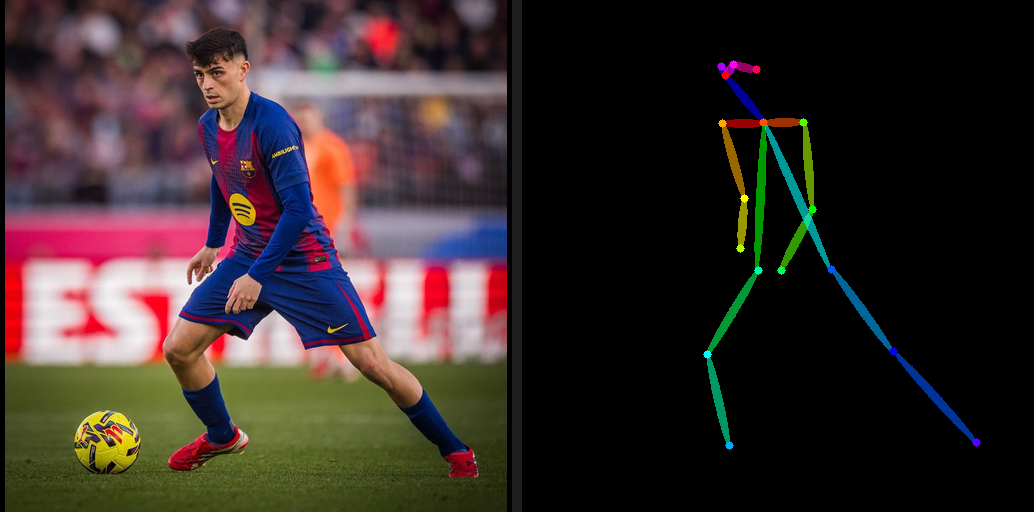

Keypoints kept: 17/18


In [6]:
from google.colab import files
from PIL import Image, ImageOps, UnidentifiedImageError
import io, math, numpy as np, cv2

uploaded = files.upload()
assert uploaded, 'No file uploaded.'
_name = next(iter(uploaded))
try:
    input_image = Image.open(io.BytesIO(uploaded[_name]))
except UnidentifiedImageError:
    raise SystemError(
        f"Could not decode '{_name}'. If it's an iPhone HEIC photo, re-run Cell 1 "
        "first (it installs pillow-heif), or re-save the image as PNG/JPG and re-upload."
    )
input_image = ImageOps.exif_transpose(input_image).convert('RGB')  # fix sideways phone photos
print(f'Loaded {_name}: {input_image.size}')

TARGET = 512
CONF_THR = 0.4   # keypoint confidence to keep

# ---- Run YOLO pose on the original (full-resolution) image ----
results = yolo_pose.predict(np.array(input_image), verbose=False, conf=0.25)[0]
assert results.keypoints is not None and len(results.keypoints) > 0, 'No person detected.'

# Most confident detection (more reliable than "largest" for crowded scenes)
det_confs = results.boxes.conf.cpu().numpy()
best = int(det_confs.argmax())
box  = results.boxes.xyxy[best].cpu().numpy()
kpts_xy   = results.keypoints.xy[best].cpu().numpy()
kpts_conf = results.keypoints.conf[best].cpu().numpy()
print(f'Detected {len(det_confs)} person(s). Using #{best} (conf={det_confs[best]:.2f})')

# ---- Crop tightly around the person, then letterbox to 512x512 ----
# This makes the skeleton fill the frame so ControlNet has a strong signal.
W, H = input_image.size
x1, y1, x2, y2 = box
bw, bh = x2 - x1, y2 - y1
side   = max(bw, bh)
pad    = 0.20 * side
cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
half   = side / 2 + pad
cx1 = max(0, int(cx - half))
cy1 = max(0, int(cy - half))
cx2 = min(W, int(cx + half))
cy2 = min(H, int(cy + half))

cropped = input_image.crop((cx1, cy1, cx2, cy2))
cw, ch = cropped.size
s      = TARGET / max(cw, ch)
nw, nh = int(round(cw * s)), int(round(ch * s))
resized = cropped.resize((nw, nh), Image.LANCZOS)
square_img = Image.new('RGB', (TARGET, TARGET), (0, 0, 0))
ox, oy = (TARGET - nw) // 2, (TARGET - nh) // 2
square_img.paste(resized, (ox, oy))

# Reject keypoints that fall outside the (slightly padded) bbox -- kills
# the long "limb" lines shooting to image corners from hallucinated kps.
in_bbox_x1 = x1 - 0.05 * bw
in_bbox_y1 = y1 - 0.05 * bh
in_bbox_x2 = x2 + 0.05 * bw
in_bbox_y2 = y2 + 0.05 * bh

def to_canvas(pt):
    return ((pt[0] - cx1) * s + ox, (pt[1] - cy1) * s + oy)

# ---- COCO-17 (YOLO) -> OpenPose-18 (what ControlNet-OpenPose was trained on) ----
YOLO_TO_OP = {
    0: 0,    # nose
    1: 15,   # l_eye
    2: 14,   # r_eye
    3: 17,   # l_ear
    4: 16,   # r_ear
    5: 5,    # l_shoulder
    6: 2,    # r_shoulder
    7: 6,    # l_elbow
    8: 3,    # r_elbow
    9: 7,    # l_wrist
    10: 4,   # r_wrist
    11: 11,  # l_hip
    12: 8,   # r_hip
    13: 12,  # l_knee
    14: 9,   # r_knee
    15: 13,  # l_ankle
    16: 10,  # r_ankle
}

op_pts = [None] * 18
for y_idx, o_idx in YOLO_TO_OP.items():
    if kpts_conf[y_idx] <= CONF_THR:
        continue
    px, py = kpts_xy[y_idx]
    if not (in_bbox_x1 <= px <= in_bbox_x2 and in_bbox_y1 <= py <= in_bbox_y2):
        continue   # hallucinated keypoint
    op_pts[o_idx] = to_canvas((px, py))

# Neck (OpenPose index 1) is synthesized from the two shoulders.
if op_pts[2] is not None and op_pts[5] is not None:
    op_pts[1] = ((op_pts[2][0] + op_pts[5][0]) / 2,
                 (op_pts[2][1] + op_pts[5][1]) / 2)

# ---- Canonical OpenPose renderer (matches controlnet_aux exactly) ----
# 1-indexed connections in OpenPose body-18 convention.
LIMB_SEQ = [[2, 3], [2, 6], [3, 4], [4, 5], [6, 7], [7, 8],
            [2, 9], [9, 10], [10, 11], [2, 12], [12, 13], [13, 14],
            [2, 1], [1, 15], [15, 17], [1, 16], [16, 18]]
COLORS = [
    [255, 0, 0], [255, 85, 0], [255, 170, 0], [255, 255, 0], [170, 255, 0], [85, 255, 0],
    [0, 255, 0], [0, 255, 85], [0, 255, 170], [0, 255, 255], [0, 170, 255], [0, 85, 255],
    [0, 0, 255], [85, 0, 255], [170, 0, 255], [255, 0, 255], [255, 0, 170], [255, 0, 85],
]
STICKWIDTH = 4

canvas = np.zeros((TARGET, TARGET, 3), dtype=np.uint8)
for i, (a1, b1) in enumerate(LIMB_SEQ):
    pa, pb = op_pts[a1 - 1], op_pts[b1 - 1]
    if pa is None or pb is None:
        continue
    xs = np.array([pa[0], pb[0]])
    ys = np.array([pa[1], pb[1]])
    mX, mY = float(xs.mean()), float(ys.mean())
    length = float(np.hypot(xs[0] - xs[1], ys[0] - ys[1]))
    angle  = math.degrees(math.atan2(ys[0] - ys[1], xs[0] - xs[1]))
    polygon = cv2.ellipse2Poly((int(mX), int(mY)),
                               (int(length / 2), STICKWIDTH),
                               int(angle), 0, 360, 1)
    cur = canvas.copy()
    cv2.fillConvexPoly(cur, polygon, COLORS[i])
    canvas = cv2.addWeighted(canvas, 0.4, cur, 0.6, 0)

for i, p in enumerate(op_pts):
    if p is None:
        continue
    cv2.circle(canvas, (int(p[0]), int(p[1])), 4, COLORS[i], -1)

pose_image = Image.fromarray(canvas)

# ---- Side-by-side preview ----
preview = Image.new('RGB', (TARGET * 2 + 10, TARGET), (30, 30, 30))
preview.paste(square_img, (0, 0))
preview.paste(pose_image, (TARGET + 10, 0))
display(preview)
print(f'Keypoints kept: {sum(p is not None for p in op_pts)}/18')


## Cell 3 - Generate the avatar

DPM-Solver++ at 20 steps, 512x512 on a T4 finishes in well under 30 s. Edit `prompt` / `negative_prompt` / `seed` to taste.

[Stage 2] SD + ControlNet done in 6.11 s  (raw avatar)
[Stage 2.5] whole-figure hires fix (strength=0.3) in 3.95 s
[Stage 3] GFPGAN skipped (masked character).
[Total]   10.05 s


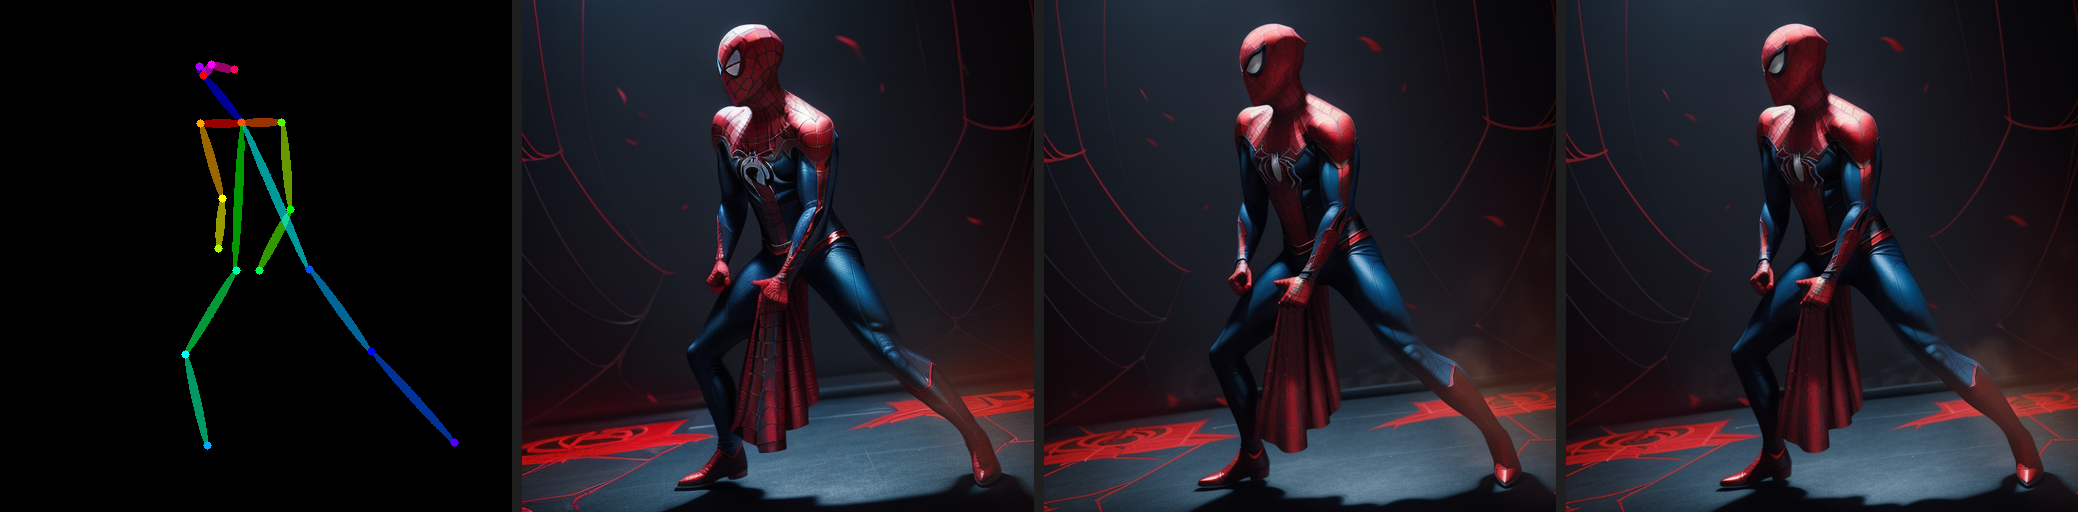

pose  |  raw SD  |  +detailer  |  final
Saved avatar.png (final)


In [7]:
import time, torch, numpy as np, cv2
from PIL import Image, ImageFilter

# ── Character config ──────────────────────────────────────────────────────
# MASKED_CHARACTER=True  -> skip face detailer + GFPGAN (no real face needed);
#                          instead sharpen the WHOLE figure (costume detail).
# MASKED_CHARACTER=False -> face detailer (stage 2.5) + GFPGAN (stage 3) path.
MASKED_CHARACTER = True

prompt = (
    'full body spider-man, red and blue suit with black web pattern, '
    'spider emblem on chest, dynamic superhero pose, cinematic lighting, '
    'highly detailed costume, sharp focus, comic-book movie still, masterpiece'
)
negative_prompt = (
    'blurry, low quality, deformed, mutated, extra limbs, extra fingers, '
    'missing fingers, bad anatomy, watermark, text, logo, '
    'plain clothes, bare face, ugly'
)

seed = 42
num_inference_steps = 28          # freed budget (no GFPGAN face work) -> crisper
guidance_scale = 7.0
controlnet_conditioning_scale = 1.2   # tight pose lock; safe with a masked face

# detailer knobs
face_denoise   = 0.5    # used when MASKED_CHARACTER=False
figure_denoise = 0.30   # used when MASKED_CHARACTER=True (whole-figure hires fix)

generator = torch.Generator(device='cuda').manual_seed(seed)

# ── Stage 2: SD 1.5 + ControlNet (skeleton + prompt -> avatar) ────────────
torch.cuda.synchronize(); t0 = time.time()
with torch.inference_mode():
    out = pipe(
        prompt=prompt, negative_prompt=negative_prompt, image=pose_image,
        num_inference_steps=num_inference_steps, guidance_scale=guidance_scale,
        controlnet_conditioning_scale=controlnet_conditioning_scale,
        width=512, height=512, generator=generator,
    )
torch.cuda.synchronize(); t_sd = time.time() - t0
avatar_raw = out.images[0]
print(f'[Stage 2] SD + ControlNet done in {t_sd:.2f} s  (raw avatar)')

avatar_hires = avatar_raw.copy()
t2 = time.time()

if MASKED_CHARACTER:
    # ── Stage 2.5 (masked): whole-figure hires fix to sharpen the costume ──
    big = avatar_raw.resize((768, 768), Image.LANCZOS)   # give detail real pixels
    g2 = torch.Generator(device='cuda').manual_seed(seed)
    with torch.inference_mode():
        big_fixed = img2img(
            prompt=prompt, negative_prompt=negative_prompt, image=big,
            strength=figure_denoise, num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale, generator=g2,
        ).images[0]
    avatar_hires = big_fixed.resize((512, 512), Image.LANCZOS)
    stage_note = f'whole-figure hires fix (strength={figure_denoise})'
else:
    # ── Stage 2.5 (real face): re-render just the head crop at full 512 res ──
    HEAD_IDX = [0, 1, 14, 15, 16, 17]   # nose, neck, eyes, ears
    head_pts = [op_pts[i] for i in HEAD_IDX if op_pts[i] is not None]
    if len(head_pts) >= 2:
        xs = [p[0] for p in head_pts]; ys = [p[1] for p in head_pts]
        cx, cy = float(np.mean(xs)), float(np.mean(ys))
        spread = max(max(xs) - min(xs), max(ys) - min(ys))
        half = max(spread * 1.6, 90)
        fx1 = max(0, int(cx - half)); fy1 = max(0, int(cy - half))
        fx2 = min(512, int(cx + half)); fy2 = min(512, int(cy + half))
        face_crop = avatar_raw.crop((fx1, fy1, fx2, fy2))
        bw, bh = face_crop.size
        face_up = face_crop.resize((512, 512), Image.LANCZOS)
        g2 = torch.Generator(device='cuda').manual_seed(seed)
        with torch.inference_mode():
            face_fixed = img2img(
                prompt='a detailed realistic face, ' + prompt,
                negative_prompt=negative_prompt, image=face_up,
                strength=face_denoise, num_inference_steps=num_inference_steps,
                guidance_scale=guidance_scale, generator=g2,
            ).images[0]
        face_back = face_fixed.resize((bw, bh), Image.LANCZOS)
        cv2_mask = np.zeros((bh, bw), np.uint8)
        cv2.rectangle(cv2_mask, (int(bw*0.12), int(bh*0.12)),
                      (int(bw*0.88), int(bh*0.88)), 255, -1)
        mask = Image.fromarray(cv2_mask).filter(ImageFilter.GaussianBlur(bw * 0.08))
        avatar_hires.paste(face_back, (fx1, fy1), mask)
        stage_note = 'face detailer'
    else:
        stage_note = 'SKIPPED (no head keypoints)'

t_face = time.time() - t2
print(f'[Stage 2.5] {stage_note} in {t_face:.2f} s')

# ── Stage 3: GFPGAN — only for real faces (skipped for masked characters) ──
t3 = time.time()
if MASKED_CHARACTER:
    avatar_final = avatar_hires
    t_gfp = 0.0
    print('[Stage 3] GFPGAN skipped (masked character).')
else:
    bgr = cv2.cvtColor(np.array(avatar_hires), cv2.COLOR_RGB2BGR)
    _, _, restored_bgr = face_restorer.enhance(
        bgr, has_aligned=False, only_center_face=False, paste_back=True, weight=0.5)
    avatar_final = Image.fromarray(cv2.cvtColor(restored_bgr, cv2.COLOR_BGR2RGB))
    t_gfp = time.time() - t3
    print(f'[Stage 3] GFPGAN done in {t_gfp:.2f} s')

print(f'[Total]   {t_sd + t_face + t_gfp:.2f} s')

# ── Comparison: pose | raw SD | detailed | final ──────────────────────────
panel = Image.new('RGB', (512 * 4 + 30, 512), (30, 30, 30))
for i, im in enumerate([pose_image, avatar_raw, avatar_hires, avatar_final]):
    panel.paste(im, (i * (512 + 10), 0))
display(panel)
print('pose  |  raw SD  |  +detailer  |  final')

avatar_final.save('avatar.png')
print('Saved avatar.png (final)')


## Cell 4 (OPTIONAL) - Pose-driven video with AnimateDiff + ControlNet

**This whole section is independent — delete this markdown cell and the code cell below to remove the video feature entirely. Nothing in Cells 1–3 depends on it.**

It needs Cell 1 to have run (reuses `yolo_pose`, `controlnet`, `SD_MODEL`, `device`, `dtype`). You upload a **short driving video** (a few seconds, one person, filling the frame); it extracts a pose skeleton per frame and generates a temporally-consistent clip with [AnimateDiff](https://github.com/guoyww/AnimateDiff). A masked character (Spider-Man) is ideal here — there's no face to flicker between frames.

Note: video is heavier than a single image — expect **~1–2 minutes** for a 16-frame clip on a T4 (the 30 s budget applies to single-image generation, not video).

Loading AnimateDiff motion adapter...


config.json:   0%|          | 0.00/455 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Keyword arguments {'safety_checker': None, 'requires_safety_checker': False} are not expected by AnimateDiffControlNetPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

AnimateDiff pipeline ready.


Saving IMG_2555.MOV to IMG_2555.MOV
Built 16 skeleton frames from "IMG_2555.MOV".
Generated 16 frames in 80.0 s
Saved spiderman.mp4 and spiderman.gif


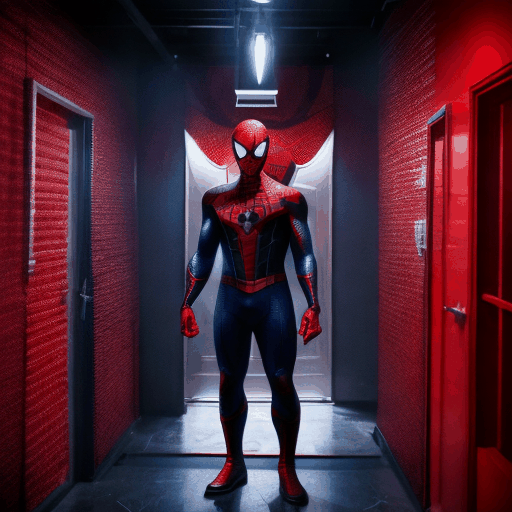

In [8]:
# ============================================================================
# CELL 4 (OPTIONAL, DELETABLE) — pose-driven video via AnimateDiff + ControlNet
# Self-contained. Requires only that Cell 1 has run.
# ============================================================================
import subprocess, sys, io, math, time
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'imageio', 'imageio-ffmpeg'])

import torch, numpy as np, cv2
from PIL import Image
from google.colab import files
from IPython.display import Image as IPyImage, display
from diffusers import AnimateDiffControlNetPipeline, MotionAdapter, DDIMScheduler
from diffusers.utils import export_to_gif, export_to_video

# ---- Settings ----
NUM_FRAMES   = 16          # AnimateDiff works best at 16; raise carefully (VRAM/time)
TARGET       = 512
VIDEO_PROMPT = (
    'full body spider-man, red and blue suit with black web pattern, '
    'spider emblem on chest, dynamic action, cinematic lighting, '
    'highly detailed costume, comic-book movie still'
)
VIDEO_NEG = ('blurry, low quality, deformed, extra limbs, bad anatomy, '
             'watermark, text, plain clothes, bare face')

# ---- Self-contained OpenPose skeleton renderer (whole-frame, for temporal stability) ----
_YOLO_TO_OP = {0:0,1:15,2:14,3:17,4:16,5:5,6:2,7:6,8:3,9:7,10:4,
               11:11,12:8,13:12,14:9,15:13,16:10}
_LIMB_SEQ = [[2,3],[2,6],[3,4],[4,5],[6,7],[7,8],[2,9],[9,10],[10,11],
             [2,12],[12,13],[13,14],[2,1],[1,15],[15,17],[1,16],[16,18]]
_COLORS = [[255,0,0],[255,85,0],[255,170,0],[255,255,0],[170,255,0],[85,255,0],
           [0,255,0],[0,255,85],[0,255,170],[0,255,255],[0,170,255],[0,85,255],
           [0,0,255],[85,0,255],[170,0,255],[255,0,255],[255,0,170],[255,0,85]]

def frame_to_skeleton(frame_rgb):
    """np RGB frame -> 512x512 OpenPose skeleton PIL (whole-frame letterbox)."""
    h, w = frame_rgb.shape[:2]
    s = TARGET / max(w, h)
    nw, nh = int(round(w*s)), int(round(h*s))
    ox, oy = (TARGET-nw)//2, (TARGET-nh)//2
    res = yolo_pose.predict(frame_rgb, verbose=False, conf=0.25)[0]
    canvas = np.zeros((TARGET, TARGET, 3), np.uint8)
    if res.keypoints is None or len(res.keypoints) == 0:
        return Image.fromarray(canvas)
    b = int(res.boxes.conf.cpu().numpy().argmax())
    kxy = res.keypoints.xy[b].cpu().numpy(); kcf = res.keypoints.conf[b].cpu().numpy()
    pts = [None]*18
    for yi, oi in _YOLO_TO_OP.items():
        if kcf[yi] > 0.4:
            pts[oi] = (kxy[yi][0]*s+ox, kxy[yi][1]*s+oy)
    if pts[2] and pts[5]:
        pts[1] = ((pts[2][0]+pts[5][0])/2, (pts[2][1]+pts[5][1])/2)
    for i,(a1,b1) in enumerate(_LIMB_SEQ):
        pa, pb = pts[a1-1], pts[b1-1]
        if pa is None or pb is None: continue
        mX,mY = (pa[0]+pb[0])/2, (pa[1]+pb[1])/2
        length = math.hypot(pa[0]-pb[0], pa[1]-pb[1])
        ang = math.degrees(math.atan2(pa[1]-pb[1], pa[0]-pb[0]))
        poly = cv2.ellipse2Poly((int(mX),int(mY)), (int(length/2),4), int(ang),0,360,1)
        cur = canvas.copy(); cv2.fillConvexPoly(cur, poly, _COLORS[i])
        canvas = cv2.addWeighted(canvas, 0.4, cur, 0.6, 0)
    for i,p in enumerate(pts):
        if p: cv2.circle(canvas, (int(p[0]),int(p[1])), 4, _COLORS[i], -1)
    return Image.fromarray(canvas)

# ---- Load AnimateDiff motion adapter + build the video pipeline (reuses controlnet) ----
print('Loading AnimateDiff motion adapter...')
adapter = MotionAdapter.from_pretrained(
    'guoyww/animatediff-motion-adapter-v1-5-2', torch_dtype=dtype)
vpipe = AnimateDiffControlNetPipeline.from_pretrained(
    SD_MODEL, motion_adapter=adapter, controlnet=controlnet,
    torch_dtype=dtype, safety_checker=None, requires_safety_checker=False,
)
vpipe.scheduler = DDIMScheduler.from_pretrained(
    SD_MODEL, subfolder='scheduler', clip_sample=False,
    timestep_spacing='linspace', beta_schedule='linear', steps_offset=1)
vpipe.enable_vae_slicing()
vpipe.enable_model_cpu_offload()      # keeps it inside T4 VRAM
vpipe.set_progress_bar_config(disable=True)
print('AnimateDiff pipeline ready.')

# ---- Upload a short driving video ----
up = files.upload()
vname = next(iter(up))
with open(vname, 'wb') as f:
    f.write(up[vname])

cap = cv2.VideoCapture(vname)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
idxs = np.linspace(0, max(total-1, 0), NUM_FRAMES).astype(int) if total else range(NUM_FRAMES)
cond_frames = []
for fi in idxs:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fi))
    ok, frame = cap.read()
    if not ok: break
    cond_frames.append(frame_to_skeleton(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
cap.release()
n = len(cond_frames)
assert n > 0, 'Could not read frames / no pose detected.'
print(f'Built {n} skeleton frames from "{vname}".')

# ---- Generate the clip ----
t0 = time.time()
gen = torch.Generator(device='cpu').manual_seed(42)
with torch.inference_mode():
    result = vpipe(
        prompt=VIDEO_PROMPT, negative_prompt=VIDEO_NEG,
        num_frames=n, conditioning_frames=cond_frames,
        width=TARGET, height=TARGET,
        num_inference_steps=20, guidance_scale=7.5,
        controlnet_conditioning_scale=1.0, generator=gen,
    )
frames = result.frames[0]
print(f'Generated {len(frames)} frames in {time.time()-t0:.1f} s')

# ---- Save + preview ----
export_to_gif(frames, 'spiderman.gif')
try:
    export_to_video(frames, 'spiderman.mp4', fps=8)
    print('Saved spiderman.mp4 and spiderman.gif')
except Exception as e:
    print('mp4 export failed (gif still saved):', e)
display(IPyImage(filename='spiderman.gif'))
